# **Materiale aggiuntivo - Numpy e Elaborazione di Immagini**



### **Obiettivi**
1. Numpy e Matplotlib
2. Immagini e tensori
3. Manipolazione di immagini con NumPy e OpenCV




# **Numpy**
Numpy è una libreria del linguaggio Python che permette di definire e manipolare vettori e matrici multidimensionali.

Fra le routines che Numpy mette a disposizone troviamo funzioni di sorting, do manipolazione della forma degli array, funzioni per fare trasformate di Fourier, operazioni di algebra lineare di base, calcoli statistici, e altro.

Di seguito vengono esposte le principali funzionalità messe a disposizione da Numpy. Per una lista completa si rimanda alla [documentazione ufficiale](https://numpy.org/doc/stable/reference/index.html).


Importiamo la libreria

In [ ]:
import numpy as np

## Array

Al contrario delle liste di Python, gli array di Numpy (**ndarray** - n-dimensional array) sono omogenei, cioè possono contenere solamente elementi dello stesso tipo.

In [ ]:
# Definisce un vettore contenente gli elementi da 0 a 5
vector = np.array([0, 1, 2, 3, 4, 5])
print(type(vector))
print('Contenuto di vector:', vector)
lista = [1,2,3,4,5]
print(lista)

<class 'numpy.ndarray'>
Contenuto di vector: [0 1 2 3 4 5]
[1, 2, 3, 4, 5]


Si noti che in Numpy un array monodimensionale viene rappresentato come vettore riga, mentre di solito in matematica per vettore ci si riferisce a vettori colonna.

Si può accedere ai singoli elementi con la sintassi vista per liste e tuple.

In [ ]:
# Accesso al primo elemento del vettore
print(vector[0])
#accesso all'ultimo elemento del vettore
print(vector[-1])

# Accesso in scrittura
vector[2] = 5
print(vector)

0
5
[0 1 5 3 4 5]


Numpy è in grado di gestire **ndarray** multidimensionali.

Di seguito un esempio di dichiarazione di array di più dimensioni

In [ ]:
scalare = np.array(1)
arr1d = np.array([1,2,3,4,5])
arr2d = np.array([ [1,2,3], [4,5,6] ] ) #una matrice
arr3d = np.array([ [ [1,2,3],[3,4,5] ] , [ [5,6,7 ],[7,8,9] ] ])
arr5d = np.array( [1,2,3], ndmin=5)

print( scalare) #provali
#print( scalare.ndim )
#print( arr1d.ndim )
#print( arr2d.ndim )
#print( arr3d.ndim )
#print( arr5d.ndim )

#Accesso agli elementi di una matrice
print(arr2d[1][2])
#SIntassi equivalente
print(arr2d[1,2])

1
3
6


Numpy mette a disposizione diverse funzioni per la creazione degli array

In [ ]:
#array NumPy con valori equamente spaziati all'interno di un intervallo specificato
print(np.arange( 0, 50, 3))

# Matrice 2x2 inizializzata con tutti gli elementi a 0
print(np.zeros((2,2)))

#Matrice 1x2 inizializzata con tutti gli elementi
print(np.ones((1,2)))

#matrice 2x2 inizializzata con tutti gli elementi a un valore costante
print(np.full((2,2), 3))

#matrice identità 3x3
print(np.eye(4))


[ 0  3  6  9 12 15 18 21 24 27 30 33 36 39 42 45 48]
[[0. 0.]
 [0. 0.]]
[[1. 1.]]
[[3 3]
 [3 3]]
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


array([[6, 3, 7, 4],
       [6, 9, 2, 6],
       [7, 4, 3, 7],
       [7, 2, 5, 4]])

## Shape e Reshape
Si definisce *rank* il numero di dimensioni di un array e **shape** una tupla di interi che esprimono la lunghezza di ciascuna dimensione. Nell'esempio vector ha un ndarray può essere manipolato in maniera tale da poter creare un array con shape differente a partire dal contenuto iniziale.

Rank (Dimensioni):

È il numero di "livelli" di dati
- Array 1D: Come una lista (1 livello)
- Array 2D o matrice: Come una tabella (2 livelli: righe + colonne)
- Array 3D: Come un cubo (3 livelli)

Shape (Forma):

È una tupla che dice quanti elementi ci sono in ogni dimensione
- (2,3) = 2 righe × 3 colonne
- (6,) = 6 elementi in un'unica riga

In [ ]:
print('Rank di vector:', len(vector.shape))
print('Shape di vector :', vector.shape)

print('Rank di matrix:', len(arr2d.shape))
print('Shape di matrix :', arr2d.shape)

Rank di vector: 1
Shape di vector : (6,)
Rank di matrix: 2
Shape di matrix : (2, 3)


Con **reshape** un ndarray può essere manipolato in maniera tale da poter creare un array con shape differente a partire dal contenuto iniziale.

In [ ]:
# Trasformazione in vettore colonna
column_vector = vector.reshape((6, 1))

print('Contenuto di column_vector:\n', column_vector)

#per ritornare al vettore originale
original_vector=column_vector.reshape((6,))
print(original_vector)


Contenuto di column_vector:
 [[0]
 [1]
 [5]
 [3]
 [4]
 [5]]
[0 1 5 3 4 5]


## Tipi di dati
Il tipo di dato degli elementi viene automaticamente inferito da Numpy oppure può essere specificato nella funzione di inizializzazione come parametro opzionale

In [ ]:
x = np.array([1, 2]) # Numpy sceglie il tipo di dati
print(x.dtype)

x = np.array([1.0, 2.0]) # Numpy sceglie il tipo di dati
print(x.dtype)

x = np.array([1, 2], dtype=np.int64) # Forza un tipo di dati
print(x.dtype)

int64
float64
int64


## Slicing
Lo slicing si applica anche agli ndarray ma, a differenza di quanto avviene per le liste, è possibile applicarlo a ogni dimensione dell'array.

> **np_array[ start : end , start : end ]**

Creiamo una matrice di 4x4 valori causali

In [ ]:
# Imposta il seed per la riproducibilità
np.random.seed(42)
random_matrix = np.random.randint(0, 10, size=(4,4)) # Genera una matrice di 4x4 numeri casuali interi tra 0 e 9 (inclusi)
random_matrix

array([[6, 3, 7, 4],
       [6, 9, 2, 6],
       [7, 4, 3, 7],
       [7, 2, 5, 4]])

In [ ]:
first_raw = random_matrix[0] #prendi la prima riga
third_col = random_matrix[:,2]#prendi la terza colonna
two_cols = random_matrix[:,1:3]#prendi la seconda e la terza colonna

small_matrix = random_matrix[1:3,1:3] # quali elementi sono ?

print(f"prima riga = {first_raw}")
print(f"terza colonna = {third_col}")
print(f"seconda e terza colonna\n{two_cols}")

prima riga = [6 3 7 4]
terza colonna = [7 2 3 5]
seconda e terza colonna
[[3 7]
 [9 2]
 [4 3]
 [2 5]]


In [ ]:
print(f"Matrice piu piccola\n{small_matrix}")

Matrice piu piccola
[[9 2]
 [4 3]]


In [ ]:
# Uno slice crea una vista, non una copia dei dati
# Modificare uno slice equivale a modificare l'ndarray originale
print(random_matrix[0, 1])
small_matrix[0, 0] = 77
print(random_matrix[0, 1])
print(small_matrix)

3
3
[[77  2]
 [ 4  3]]


## Operazioni algebriche tra vettori

In [ ]:
# Reminder: vector = [0, 1, 2, 3, 4, 5]

# Moltiplicazione di un vettore per uno scalare
vector_scalar_prod = vector * 5

# Divisione di un vettore per uno scalare
vector_scalar_div = vector / 5

print('Prodotto per uno scalare:\n', vector_scalar_prod)
print('Divisione per uno scalare:\n', vector_scalar_div)

Prodotto per uno scalare:
 [ 0  5 25 15 20 25]
Divisione per uno scalare:
 [0.  0.2 1.  0.6 0.8 1. ]


In [ ]:
vect1 = np.array([1,2,6])
vect2 = np.array([5,2,3])

# Somma tra vettori
vector_sum = vect1 + vect2

# Sottrazione tra vettori
vector_sub = vect1 - vect2

print('Somma:\n', vector_sum)
print('Sottrazione:\n', vector_sub)


Somma:
 [6 4 9]
Sottrazione:
 [-4  0  3]


In [ ]:
ones = np.ones( shape=(4,4) ) #Crea una matrice 4x4 con valore 1
ones
sum_matrix = random_matrix + ones #somma le due matrici e ne crea una nuova
sum_matrix
mul_matrix = random_matrix * (sum_matrix/2) #moltiplica il contenuto di random per un altra matrice che prima ha diviso per due
mul_matrix

array([[2.100e+01, 6.000e+00, 2.800e+01, 1.000e+01],
       [2.100e+01, 3.003e+03, 3.000e+00, 2.100e+01],
       [2.800e+01, 1.000e+01, 6.000e+00, 2.800e+01],
       [2.800e+01, 3.000e+00, 1.500e+01, 1.000e+01]])

Nota: L'operatore '+' applicato a due liste di python esegue una concatenazione. Applicato a un ndarray si ottiene una somma.

## Operazioni algebriche tra matrici
Numpy mette a disposizione diverse funzioni frequentemente utilizzate nel calcolo matriciale quali: calcolo della trasposta, dell'inversa, del determinante, del prodotto tra matrici, ecc.

In [ ]:
# Creiamo due matrici 2x2 per gli esempi
A = np.array([[1, 2],
              [3, 4]])

B = np.array([[5, 6],
              [7, 8]])

print("Matrice A:\n", A)
print("\nMatrice B:\n", B)

# --- 1. Calcolo del determinante ---
# Il determinante è un valore scalare che caratterizza le matrici quadrate
# Utile per verificare se una matrice è invertibile (det ≠ 0)
det_A = np.linalg.det(A)
print(f"\nDeterminante di A: {det_A:.2f}")  # Output: -2.00

# --- 2. Calcolo dell'inversa ---
# L'inversa di una matrice A è una matrice A⁻ tale che A * A⁻ = I (matrice identità)
# Esiste solo se det(A) ≠ 0
inv_A = np.linalg.inv(A)
print("\nInversa di A:\n", inv_A)


# --- 3. Calcolo della trasposta ---
# La trasposta scambia righe e colonne
# Elemento [i,j] diventa [j,i]
trasposta_A = A.T
print("\nTrasposta di A:\n", trasposta_A)


# --- 4. Somma di matrici ---
# Somma elemento per elemento (stessa dimensione)
somma = A + B
print("\nSomma A + B:\n", somma)


# --- 5. Sottrazione di matrici ---
# Sottrazione elemento per elemento (stessa dimensione)
sottrazione = A - B
print("\nSottrazione A - B:\n", sottrazione)


# --- 6. Moltiplicazione di matrici ---
# Due tipi di moltiplicazione:

# a) Prodotto scalare (righe per colonne)
# Numero colonne di A deve essere uguale a numero righe di B
prodotto = np.dot(A, B)  # Oppure A @ B
print("\nProdotto matriciale A @ B:\n", prodotto)


# b) Moltiplicazione elemento per elemento
element_wise = A * B
print("\nMoltiplicazione elemento per elemento A * B:\n", element_wise)

Matrice A:
 [[1 2]
 [3 4]]

Matrice B:
 [[5 6]
 [7 8]]

Determinante di A: -2.00

Inversa di A:
 [[-2.   1. ]
 [ 1.5 -0.5]]

Trasposta di A:
 [[1 3]
 [2 4]]

Somma A + B:
 [[ 6  8]
 [10 12]]

Sottrazione A - B:
 [[-4 -4]
 [-4 -4]]

Prodotto matriciale A @ B:
 [[19 22]
 [43 50]]

Moltiplicazione elemento per elemento A * B:
 [[ 5 12]
 [21 32]]


## Operazioni avanzate
Si possono fare anche operazioni più avanzate su Numpy..

La [documentazione ufficiale](https://numpy.org/doc/stable/reference/generated/numpy.ndarray.html) di ndarray contiene la lista completa delle operazioni supportate.

# **Matplotlib**

Matplotlib è una delle librerie più conosciute per Python per la creazione e la visualizzazione di grafici.

Matplotlib mette a disposizione numerosi strumenti. L'obiettivo dell'esercitazione odierna è presentarne le principali caratteristiche. Per approfondire le conoscenze su questa libreria potete fare riferimento alla [relativa documentazione](https://matplotlib.org/3.0.3/api/api_overview.html).

Importiamo la libreria

In [ ]:
import matplotlib.pyplot as plt

Visualizziamo un semplice grafico

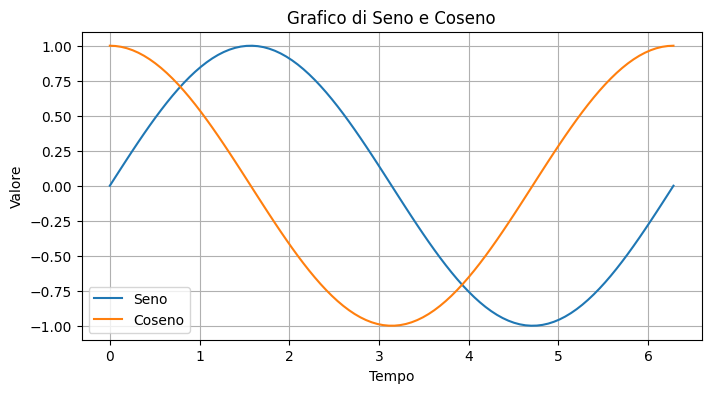

In [ ]:
#array t contiene 100 valori equidistanti distribuiti nell'intervallo da 0 a 2 * np.pi, inclusi sia 0 che 2 * np.pi.
t = np.linspace(0, 2 * np.pi, 100)

# Calcolo delle funzioni seno e coseno
sin_wave = np.sin(t)
cos_wave = np.cos(t)

# Creazione di un'area di disegno in Matplotlib e visualizzazione delle funzioni
plt.figure(figsize=(8, 4))# istanzio una nuova "figura"

plt.plot(t, sin_wave, label='Seno')  #x=t e y=seno
plt.plot(t, cos_wave, label='Coseno')#x=t e y=coseno
plt.xlabel('Tempo')
plt.ylabel('Valore')
plt.title('Grafico di Seno e Coseno')
plt.legend()
plt.grid(True)

# Mostra il grafico
plt.show()

La funzione plot può disegnare più curve in una singola chiamata, passando coppie di (x, y) in sequenza.

show(...) si occupa di creare l'immagine finale ripulendo allo stesso tempo lo stato interno mantenuto dal modulo.

Avrete anche notato che plot accetta un numero arbitrario di parametri senza nome. Questo ci permette di aggiungere un numero imprecisato di segmenti in un'unica chiamata.

In Matplolib è comune trovare funzioni che accettano un numero potenzialmente infinito di parametri geometrici e che lasciano ai parametri con nome il compito di curarne la presentazione grafica

## Istogrammi

Tramite Matplotlib è possibile costruire una grande varietà di viste. Quello che segue è un esempio di istogramma

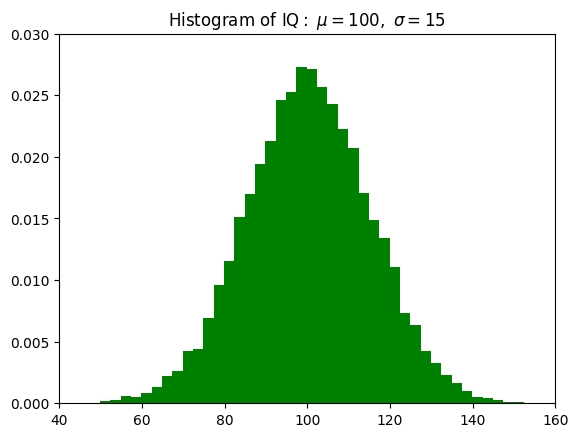

In [ ]:
# La libreria random permette di generare numeri casuali
import random

# Genera una lista di 10000 numeri presi da una distribuzione gaussiana
mu, sigma = 100, 15
x = [random.gauss(mu, sigma) for _ in range(10000)]

# La funzione utilizzata per mostrare istogrammi è hist(...)
plt.hist(x, bins=50, density=True, facecolor='green')

# Modifica di qualche opzione grafica
plt.title(r'$\mathrm{Histogram\ of\ IQ:}\ \mu=100,\ \sigma=15$')
plt.axis([40, 160, 0, 0.03])

plt.show()

# Immagini e Pixel
Le immagini digitali sono costituite da una collezione ordinata di pixel che rappresentano dei punti individuali all'interno dell'immagine.

Ad ogni pixel è associato un colore o un valore di intensità attraverso un sistema di colore. Assegnando un colore ai singoli pixel di un immagine si determina l'aspeto visivo dell'immagine.

Un sistema di colori è una rappresentazione astratta dello spazio dei colori.
Ne esistono diversi per diversi spazi di colore e i componenti che rappresentano un sistema di colore sono chiamati "canali di colore".

*   **Binary**: In un'immagine binaria, un pixel può essere solo nero o bianco, rappresentato rispettivamente con 0 o 1.

*   **Grayscale**: In questa modalità, l'intensità del grigio è espressa con un unico valore numerico. Tipicamente, il range va da 0 (nero) a 255 (bianco).


*   **RGB (Red, Green, Blu)**: Questo modello di colore utilizza tre canali, ognuno dei quali ha un range da 0 a 255 per rappresentare l'intensità del colore rosso, verde e blu del pixel.

*   **RGBA (Red, Green, Blue, Alpha)**: Simile a RGB, ma con l'aggiunta di un canale alpha per rappresentare la trasparenza. I range per i canali RGB sono da 0 a 255, mentre per il canale alpha è tipicamente da 0 (completamente trasparente) a 255 (completamente opaco).

*   **CMYK (Cyan, Magenta, Yellow, Black)**: Utilizzato nell'industria grafica, i canali CMYK hanno spesso range da 0 a 100% per rappresentare le quantità di ciascun colore.

*   **HSV e HSL ( Hue, Saturation, Value/Lightness )**: La tonalità (H) la tinta tra i colori dell'arcobaleno (0 = rosso, 255 = violetto).
La saturazione (S) indica quanto i colori sono "vividi" (0 = colori sbiaditi, 255 = colori accesi), e il valore (V) noto anche come o luminosità (L) va da 0 molto scuro a 255 molto chiaro

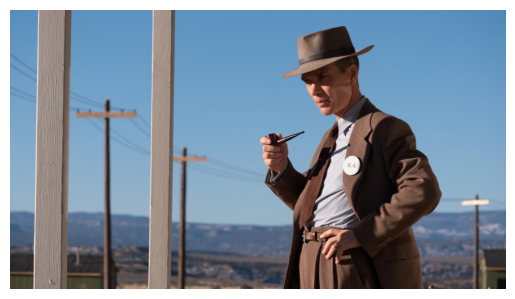

dimensioni dell'immagine: (675, 1200, 3)


In [ ]:
# Scarichiamo e visualizziamo un'immagine
import imageio.v2 as imageio
#Scarichiamo un immagine da un link drive
url="https://drive.google.com/uc?id=1oMwhUwK-tuCaAP-_2aiTyoCrLIcqkDc9"
img_oppenheimer = imageio.imread(url) #usiamo un array Numpy per rappresentare l'immagine in RGB

img = img_oppenheimer.copy().astype(np.uint16) #facciamo una copia così non lavoriamo sull'originale

# Visualizza l'immagine con Matplotlib
plt.imshow(img)
plt.axis('off')  # Nasconde gli assi
plt.show()

#Stampiamo alcune caratteristiche dell'immagine.
print(f"dimensioni dell'immagine: {img.shape}")  # (altezza x larghezza x canali)

#Immagini e Tensori
Un tensore è una struttura dati multidimensionale che consente di organizzare e gesire dati in forma di array o matrici con piu di due dimensioni.

I tensori sono molto utilizzati per gestire dati complessi e strutturati in modo flessibile.


Nell'ambito dell'apprendimento automatico e dell'analisi dei dati, come l'elaborazione delle immagini, viene immediato rappresentare un immagine con una struttura di colori RGB attraverso un tensore tridimensionale:

- una dimensione per la larghezza dell'immagine,
- una dimensione per l'altezza
- una dimensioni per i canali di colore ( rosso, verde e blue ) (qundi 3 ).




Vocabolario

> Asse o Dimensione: una particolare dimensione di un tensore.

> Shape: La lunghezza (numero di elementi) di ogni asse del tensore.

> Rango: nuero di assi del tensore. uno scalare ha rango 0, un vettore ha rango 1, una matrice ha rango 2.

> Size: numero totale di elementi in un tensore, il prodotto degli elementi nel vetore shape del tensore.


![image](https://drive.google.com/uc?id=1ru1CpMrJzt9ODprpvHnj7A9nryZjD4Mz)

![shape](https://drive.google.com/uc?id=17wmgute3XK4AOAEMpemVJbuCN7pX3PRN)

## Isolare un canale

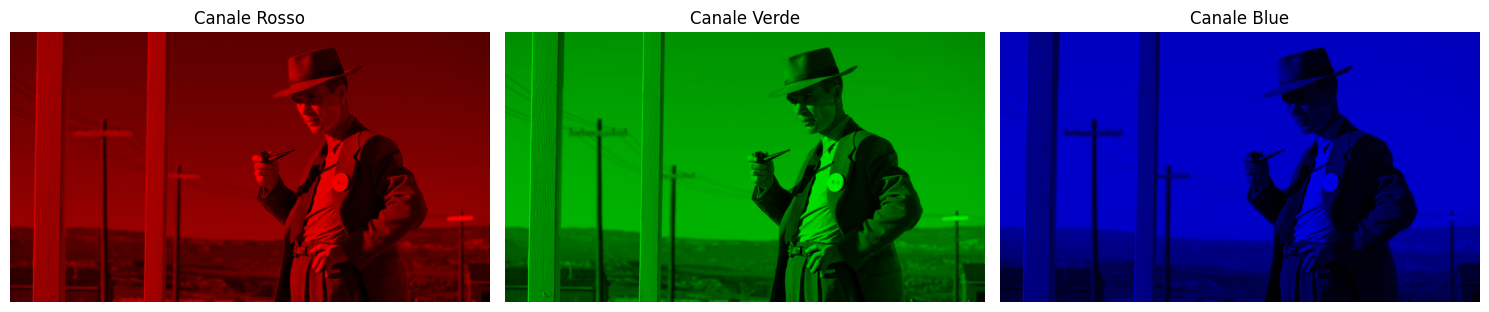

In [ ]:
# Creiamo una figura con 3 subplot orizzontali
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Faccio tre copie dell'immagine per non sovrascrivere la precedente
red = img.copy()
green = img.copy()
blue = img.copy()

# Isoliamo il canale rosso
red[:,:, 1] = 0  # metto a 0 il canale verde
red[:,:, 2] = 0  # metto a 0 il canale blue
ax1.imshow(red)
ax1.set_axis_off()  # Nasconde gli assi
ax1.set_title('Canale Rosso')

# Isoliamo il canale verde
green[:,:, 0] = 0  # metto a 0 il canale red
green[:,:, 2] = 0  # metto a 0 il canale blue
ax2.imshow(green)
ax2.set_axis_off()  # Nasconde gli assi
ax2.set_title('Canale Verde')

# Isoliamo il canale blue
blue[:,:, 0] = 0  # metto a 0 il canale red
blue[:,:, 1] = 0  # metto a 0 il canale verde
ax3.imshow(blue)
ax3.set_axis_off()  # Nasconde gli assi
ax3.set_title('Canale Blue')

# Mostriamo tutto insieme
plt.tight_layout()
plt.show()

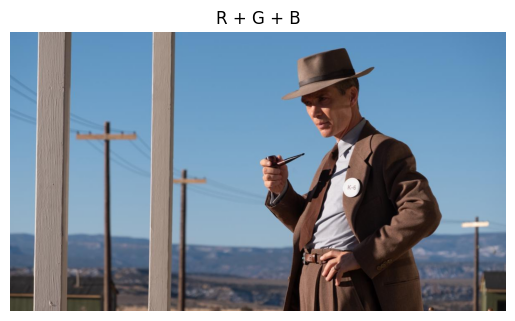

In [ ]:
#manipolazine dei canali di un immagine con numpy
rgb = red + green + blue
plt.imshow(rgb)
plt.axis('off')  # Nasconde gli assi
plt.title('R + G + B')
plt.show()

## Saturazione
Per saturazione intendiamo l'intensità o la purezza del colore di un'immagine

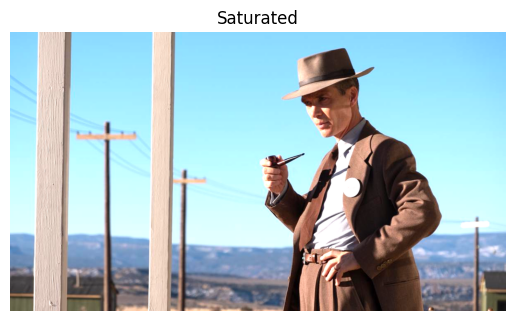

In [ ]:
#il valore del fattore di saturazione tipicamente è compreso fra  [-1, +∞]
#s = -1 completa desaturazione e si trasforma in una immagine nera.
#s = tra -1 e 0 indicano una riduzione della saturazione.
#s = 1 corrisponde a l'attuale saturazione dell'immagine .
#s > 1 indicano un aumento della saturazione.


saturation_factor = 1.5
saturated_image = img * saturation_factor
# Assicurati che i valori rimangano nel range 0-255, e poi riportali in int
saturated_image = np.clip(saturated_image, 0, 255).astype(np.uint8)

plt.imshow(saturated_image)
plt.axis('off')  # Nasconde gli assi
plt.title('Saturated')
plt.show()

## Luminosità

la luminanza è la misura fisica della luce emessa da ogni pixel e viene misurata in (cd/m²) o nits, indicando quanto luce la superficie riflette o emette in una direzione. La luminosità è invece la percezione soggettiva di questa luce da parte dell'occhio umano

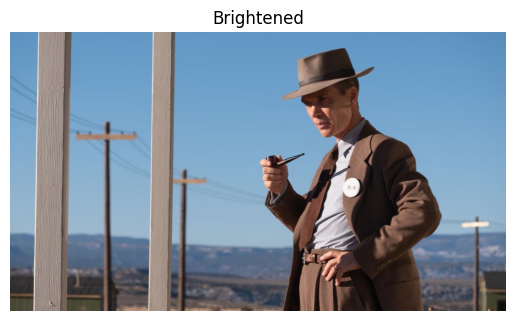

E se volessimo rendere l'immagine piu scura ?


In [ ]:
# Aumenta la luminosità aggiungendo un valore ai canali RGB

brightness_factor = 5
brightened_image = img + brightness_factor  # Aumento di 5

# Assicurati che i valori rimangano nel range 0-255
brightened_image = np.clip(brightened_image, 0, 255).astype(np.uint8)
plt.imshow(brightened_image)
plt.axis('off')  # Nasconde gli assi
plt.title('Brightened')
plt.show()

print("E se volessimo rendere l'immagine piu scura ?")

## Effetto Polaroid

Le Polaroid rendono i colori chiari più chiari e i colori scuri più scuri. Si può ottenere una buona approssimazione di questo effetto usando una variante della funzione logistica:

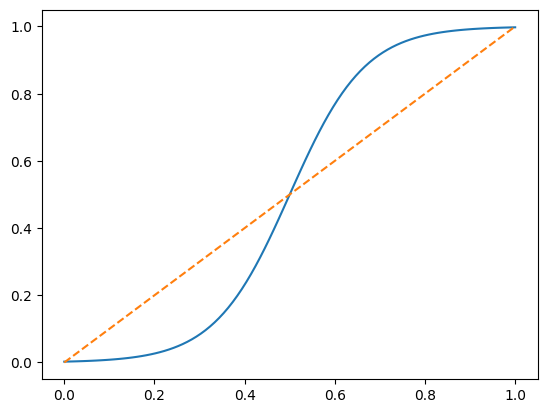

In [ ]:
def scaled_logistic(x):
    return 1 / (1 + np.exp(-12 * x + 6))

x = np.linspace(0, 1, 100)
y = scaled_logistic(x)
import matplotlib.pyplot as plt
plt.plot(x, y)
plt.plot(x, x, '--') # Mostra la retta y = x per confronto
plt.show()

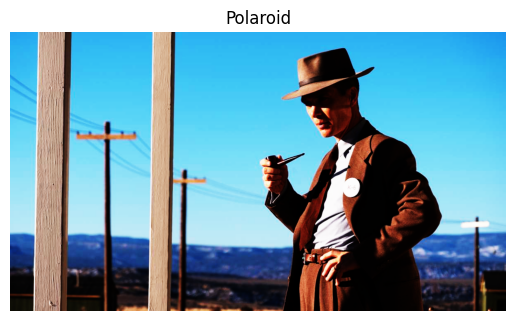

In [ ]:
def polaroid( image ):
    image = image.astype(np.float32) / 255 # Converti in range [0, 1]
    image = scaled_logistic(image)
    image = (image * 255).astype(np.uint8) # Rconverti in range [0, 255]
    return image


polaroided = polaroid( img )
plt.imshow( polaroided )
plt.axis('off')  # Nasconde gli assi
plt.title('Polaroid')
plt.show()


## OpenCV
https://opencv.org/get-started/

E' una libreria open source per la computer vision e l'image processing.

In [ ]:
import cv2

**Resize di un immagine**

Dimensioni dell'immagine del cane (416, 735, 3)
Dimensioni dell'immagine di Oppenheimer (675, 1200, 3)


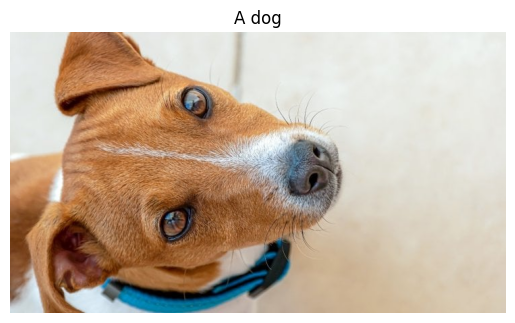

In [ ]:
url="https://drive.google.com/uc?id=1vWgkE4_TUuBJhlsZv7JdURRCM_WoYNRl"
img_dog = imageio.imread(url) #usiamo un array Numpy per rappresentare l'immagine in RGB

img2 = img_dog.copy().astype(np.uint16)
print(f"Dimensioni dell'immagine del cane {img2.shape}")
print(f"Dimensioni dell'immagine di Oppenheimer {img.shape}")
plt.imshow( img2 )
plt.axis('off')  # Nasconde gli assi
plt.title('A dog')
plt.show()

Effettuiamo un resize per dare alle due immagini la stessa dimensione

Dimensioni della nuova immagine (675, 1200, 3)
Dimensioni dell'immagine di Oppenheimer (675, 1200, 3)


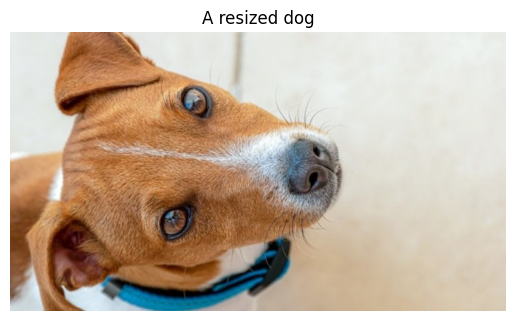

In [ ]:
import cv2

#attenzione open CV vuole prima la width e poi la height
new_shape = (img.shape[1], img.shape[0])
img2 = cv2.resize( img2, new_shape )

print(f"Dimensioni della nuova immagine {img2.shape}")
print(f"Dimensioni dell'immagine di Oppenheimer {img.shape}")

plt.imshow( img2 )
plt.axis('off')  # Nasconde gli assi
plt.title('A resized dog')
plt.show()


**Interpolazione tra due immagini**

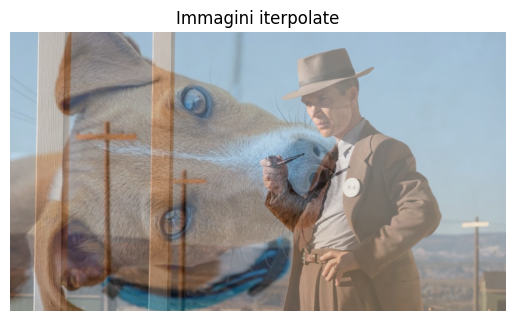

In [ ]:
def interpolate(image1, image2, coefficient):
    if image1.shape != image2.shape:
      raise ValueError("The images must have the same shape")

    if coefficient<0 or coefficient>1:
      raise ValueError("Coefficient must be in [0,1]")

    interpolated = image1 * (1 - coefficient) + image2 * coefficient
    # interpolated ora è un'immagine floating point, riconvertiamola in interi
    return interpolated.astype(np.uint8)


# 0 = prendo solo image1, 1 = prendo solo image2
interpolated = interpolate( img, img2, coefficient=0.5)

plt.imshow( interpolated )
plt.axis('off')  # Nasconde gli assi
plt.title('Immagini iterpolate')

plt.show()

Le immagini su OpenCV sono di default impostate a BGR

**Converting an image to grayscale**

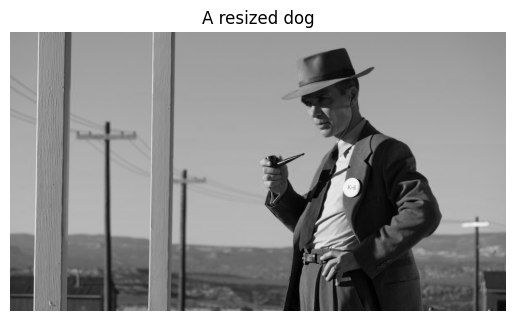

In [ ]:
# Convert to grayscale
gray_image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# Save the grayscale image
plt.imshow(gray_image, cmap='gray')
plt.axis('off')  # Nasconde gli assi
plt.title('A resized dog')
plt.show()

**Image masking**

L'image masking (mascheramento dell'immagine) è una tecnica molto utilizzata nella computer vision che ci consente di modificare o estrarre selettivamente determinate parti di un'immagine in base a criteri specifici. Il mascheramento viene impiegato per separare la regione di interesse (ROI) dal resto dell'immagine. In OpenCV, il mascheramento delle immagini viene effettuato utilizzando immagini binarie in cui i pixel assumono valori pari a 0 o 255. Questa tecnica risulta particolarmente utile per varie applicazioni di computer vision, tra cui il rilevamento di oggetti, la segmentazione e il tracking. Il mascheramento prevede la creazione di una maschera binaria o di un'immagine di sovrapposizione che viene successivamente applicata all'immagine originale, consentendoci di isolare e manipolare la specifica regione di interesse lasciando inalterato il resto dell'immagine.

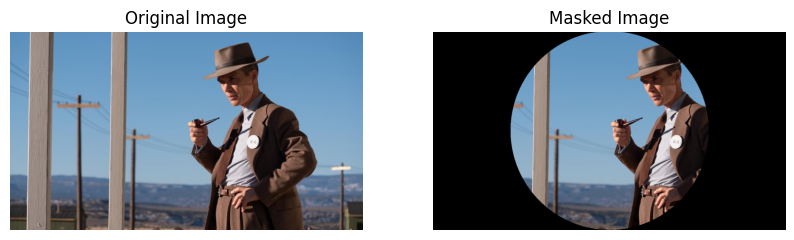

In [ ]:
#Crea una maschera nera della stessa dimensione dell'immagine
mask = np.zeros_like(img)

# Define the center and radius of the circle
height, width = img.shape[:2]
center = (width // 2, height // 2)
radius = min(center[0], center[1])

# Draw a white circle in the mask
cv2.circle(mask, center, radius, (255, 255, 255), -1)

# Apply the mask to the image
masked_image = cv2.bitwise_and(img, mask)

# Display the original image with the circular mask
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img)
ax[0].set_title('Original Image')
ax[1].imshow(masked_image)
ax[1].set_title('Masked Image')
ax[0].axis('off')
ax[1].axis('off')
plt.show()

### Blurring


I filtri vengono applicati in un'immagine per vari scopi: Riduzione del rumore, smoothing, edge detection etc

Diversi tipi di blur:

*   Average Blur: Prende un gruppo di pixel (es. 5x5) e calcola la media aritmetica di tutti i valori, poi assegna questo valore medio al pixel centrale.
*   Gaussian Blur: Si applica una gaussiana per pesare i pixels. I pixel più vicini al centro hanno più influenza, quelli lontani meno
* Median Blur: Prende i pixel vicini, li ordina dal più scuro al più chiaro, e sceglie il valore mediano







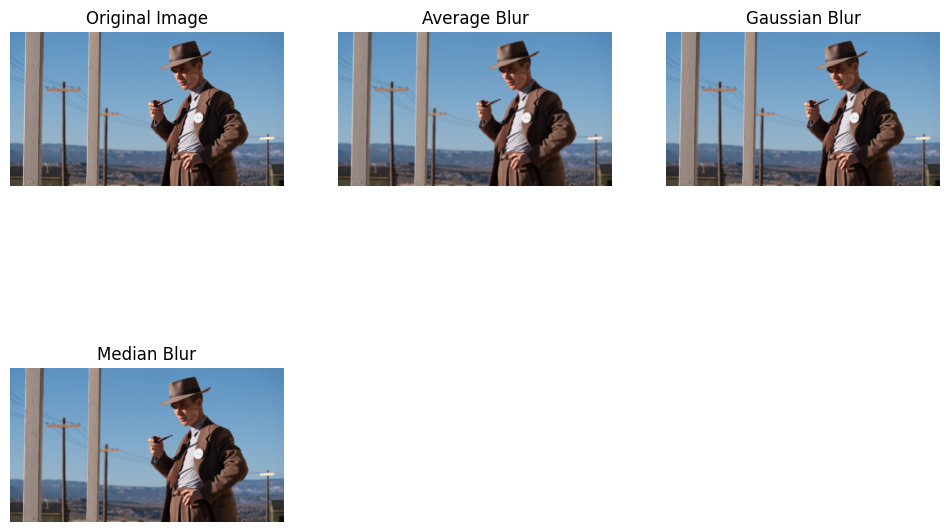

In [ ]:
rgb_img=img_oppenheimer.copy()
#rgb_img=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# Apply Average Blurring: the vanilla filter
average_blur = cv2.blur(rgb_img, (5, 5))
# Apply Gaussian Blurring: the smooth operator
gaussian_blur = cv2.GaussianBlur(rgb_img, (5, 5), 0)
# Apply Median Blurring: bye-bye, pixel zits
median_blur = cv2.medianBlur(rgb_img, 5)
# Apply Bilateral Filtering: the show-off
# Displaying the results like a proud parent
titles = ['Original Image', 'Average Blur', 'Gaussian Blur', 'Median Blur']
images = [rgb_img, average_blur, gaussian_blur, median_blur]
plt.figure(figsize=(12, 8))
for i in range(4):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')
plt.show()

**Thresholding**

E' il metodo usato per la binarizzazione di immagini. E' usato di solito nella image segmentation, quando vogliamo separare gli oggetti dal background

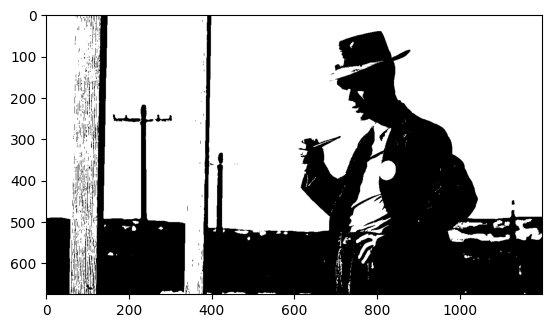

In [ ]:
# Convert image to grayscale
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply thresholding using a threshold value of 127
ret, thresh = cv2.threshold(gray_img, 127, 255, cv2.THRESH_BINARY)
plt.imshow(thresh, cmap='gray')

**Image gradient detection**
La rilevazione del gradiente dell'immagine è una tecnica fondamentale che svolge un ruolo significativo nelle applicazioni di computer vision come l'edge dectection, l'image segmentation e la feature extraction. Il gradiente rappresenta il tasso di variazione dell'intensità dei pixel attraverso l'immagine e il rilevamento dei gradienti aiuta a identificare bordi e contorni in un'immagine. OpenCV fornisce varie funzioni per calcolare i gradienti dell'immagine, come gli algoritmi di rilevamento dei bordi Sobel, Scharr, Laplacian e Canny. Questi algoritmi utilizzano approcci diversi per calcolare i gradienti e possono essere selezionati in base alle caratteristiche dell'immagine e ai requisiti specifici.

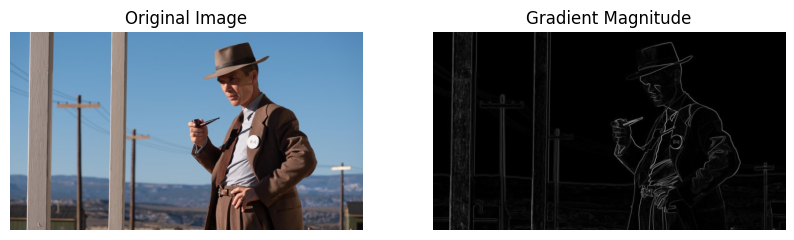

In [ ]:


# Computing the gradient in the x direction using the Scharr operator
sobel_x = cv2.Scharr(gray_img, cv2.CV_64F, 1, 0)

# Computing the gradient in the y direction using the Scharr operator
sobel_y = cv2.Scharr(gray_img, cv2.CV_64F, 0, 1)

# Computing the gradient magnitude
grad_mag = np.sqrt(sobel_x ** 2 + sobel_y ** 2)

# Normalizing the gradient magnitude to the range [0, 255]
grad_mag_norm = cv2.normalize(grad_mag, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

# Displaying the results
fig, axs = plt.subplots(1, 2, figsize=(10, 10))
axs[0].imshow(img)
axs[0].set_title("Original Image")
axs[1].imshow(grad_mag_norm, cmap="gray")
axs[1].set_title("Gradient Magnitude")
axs[0].axis('off')
axs[1].axis('off')
plt.show()

L'algoritmo di rilevamento dei bordi di Canny applica innanzitutto un filtro Gaussiano all'immagine per rimuovere il rumore, quindi calcola i gradienti di intensità presenti nell'immagine. Questi gradienti vengono successivamente utilizzati per determinare i bordi nell'immagine. La tecnica di rilevamento dei bordi di Canny è estremamente efficace nell'individuare i contorni in immagini con basso contrasto o alti livelli di rumore. In questa tecnica, i bordi rilevati sono molto precisi e possono essere utilizzati in varie applicazioni come il riconoscimento di oggetti, il tracking e la segmentazione.

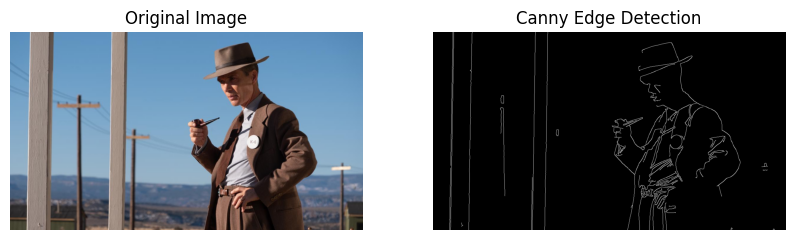

In [ ]:
# Apply Gaussian Blur to reduce noise
blurred = cv2.GaussianBlur(gray_img, (5, 5), 0)
blurred = blurred.astype(np.uint8)
# Apply Canny Edge Detection
edges = cv2.Canny(blurred, 100, 200)
# Display the original image and the edges detected image side by side
fig, axs = plt.subplots(1, 2, figsize=(10, 10))
axs[0].imshow(img)
axs[0].set_title('Original Image')
axs[1].imshow(edges, cmap='gray')
axs[1].set_title('Canny Edge Detection')
axs[0].axis('off')
axs[1].axis('off')
plt.show()

## HSV (Hue,Saturation and Value)

- Hue: ovvero la tinta tra i colori dell'arcobaleno (0 = rosso, 255 = violetto)
- Saturation: ovvero quanto i colori sono "vividi" (0 = colori sbiaditi, 255 = colori accesi)
- Value: (nota anche come Brightness), ovvero la luminosità (0 = scuro, 255 = chiaro)

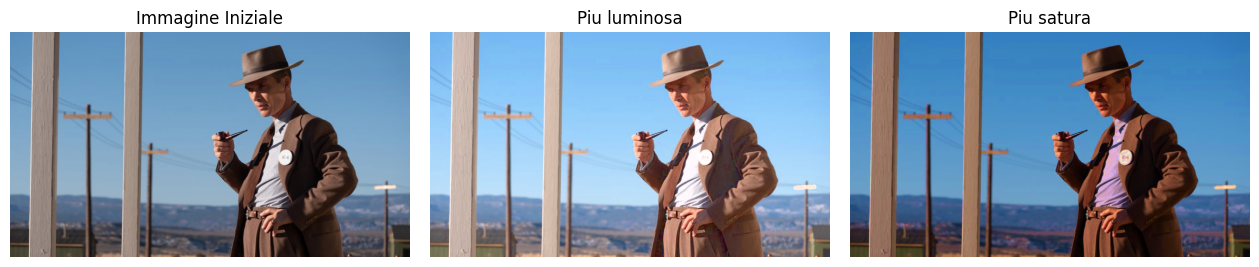

In [ ]:
img = img_oppenheimer.copy()

# Converti l'immagine RGB in HSV
image_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)



# Modifica la luminosità

hsv_brightened = image_hsv.copy().astype(np.uint16)
brightness = 50
hsv_brightened[:,:,2] =  np.clip( hsv_brightened[:,:,2] + brightness, 0,255)
hsv_brightened= hsv_brightened.astype(np.uint8)


#Modifica la saturazione
hsv_saturated = image_hsv.copy().astype(np.uint16)
saturation_factor = 55
hsv_saturated[:,:,1] = (hsv_saturated[:,:,1] + saturation_factor).clip( 0,255)
hsv_saturated = hsv_saturated.astype(np.uint8)


# Visualizza le immagini
# Stampa
image_list =[image_hsv, hsv_brightened, hsv_saturated]

titles = ['Immagine Iniziale', 'Piu luminosa', 'Piu satura']
fig, axes = plt.subplots(1, len(image_list), figsize=(16, 9))  # Crea una figura con le dimensioni appropriate

for i, (image_hsv, title) in enumerate(zip(image_list, titles)):
    img_bgr = cv2.cvtColor(image_hsv, cv2.COLOR_HSV2BGR)
    axes[i].imshow(img_bgr)
    axes[i].axis('off')
    axes[i].set_title(title)

plt.subplots_adjust(wspace=0.05, hspace=0.2)  # Aggiusta lo spazio tra le immagini
plt.show()